Global map - Mean bias 

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import xarray as xr
import xcdat as xc
import numpy as np
import os
from cartopy.util import add_cyclic_point
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap, BoundaryNorm

/global/homes/j/jungchoi/.conda/envs/pcmdi_metrics/lib/python3.10/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
#model_list =  ['MME', 'CanESM5', 'CMCC-CM2-SR5', 'CNRM-ESM2-1', 'EC-Earth3', 
#               'FGOALS-f3-L', 'HadGEM3-GC31-MM', 'IPSL-CM6A-LR', 'MIROC6', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorCPM1']
model_list =  ['MME']
#lead_yr_list = ['1', '2', '3', '4', '5', '1-5']
lead_yr_list = ['1']

output_dir = "/global/cfs/projectdirs/m4581/jungchoi/DCPP/_metrics"
output_grid_no = "144x72"

MME acc 1
[[0.56697047 0.5630026  0.5551687  ... 0.5816392  0.5750285  0.57600313]
 [0.9169167  0.9200068  0.9233105  ... 0.88082534 0.897897   0.90326583]
 [1.1834975  1.18643    1.2103013  ... 1.1450354  1.1548947  1.1590096 ]
 ...
 [0.9208219  0.942814   0.948302   ... 0.8473284  0.86258596 0.89341676]
 [0.8662317  0.87657    0.8887344  ... 0.8392692  0.8491336  0.860693  ]
 [0.9309598  0.93498534 0.93914247 ... 0.9166782  0.92172354 0.92632663]]
[[0.47959834 0.475352   0.47206807 ... 0.49119604 0.48474494 0.48863962]
 [0.8254779  0.8438217  0.86599916 ... 0.74815786 0.77869666 0.79690975]
 [1.0993989  1.1169956  1.1662797  ... 1.0426418  1.0572592  1.0648448 ]
 ...
 [0.8178127  0.8436148  0.843552   ... 0.74335575 0.7536932  0.7851698 ]
 [0.7522069  0.7652035  0.78088325 ... 0.7219372  0.733225   0.74677134]
 [0.85329986 0.8586786  0.8641887  ... 0.8347421  0.84098375 0.84708524]]
[[0.31100798 0.31820202 0.31025854 ... 0.2982504  0.30550906 0.30779976]
 [0.7041935  0.7381451  0.762

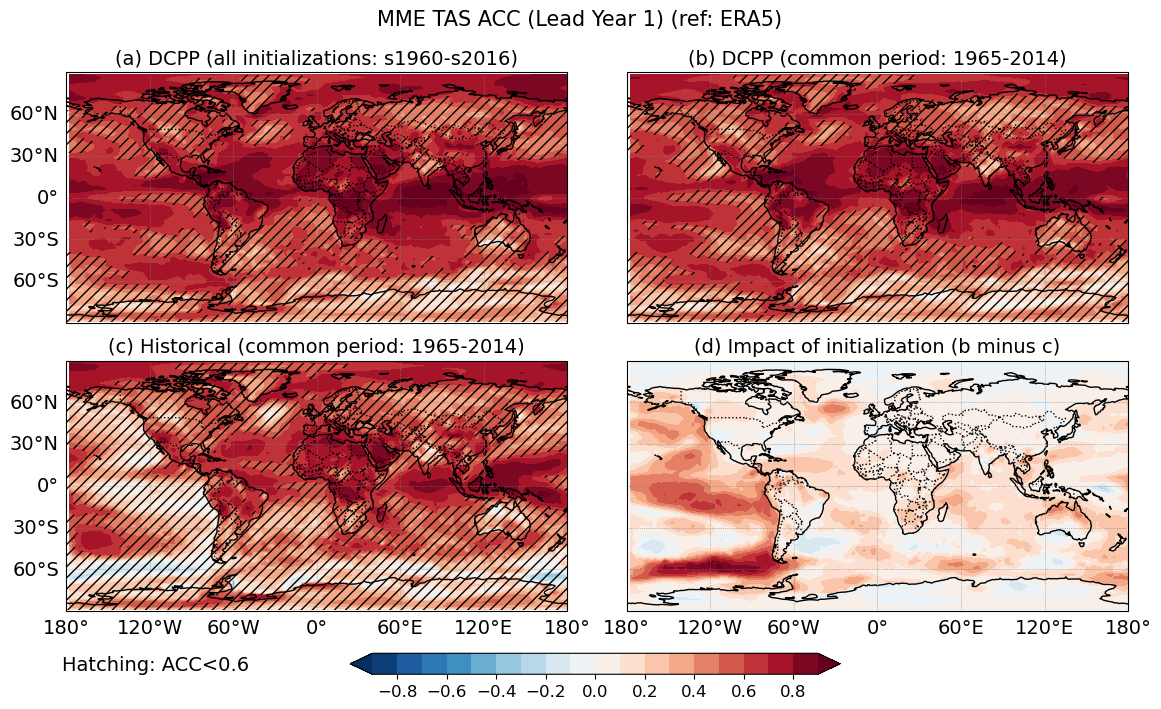

In [12]:
figout_dir = "/global/cfs/projectdirs/m4581/jungchoi/PMP/GMD2026/Fig9/_subplots"

var_name = "tas"
#var_name = "pr"

#skill_list = ['acc', 'msss', 'rpc']
skill_list = ['acc']
fig_no = "Fig10_new"

# Read model skill scores
if var_name == "tas":
    all_init = "s1960-s2016"
    comm_period = "1965-2014"
    ref = "ERA5"
    
if var_name == "pr":
    all_init = "s1978-s2016"
    comm_period = "1979-2014"
    ref = "GPCP"

for model in model_list:
        
    for skill_name in skill_list:
    
        for lead_yr in lead_yr_list:
            print(model, skill_name, lead_yr)
            
            hist_yr = "ann"
            if lead_yr == "1-5":
                hist_yr = "ann5"
            
            file_alli = f"{output_dir}/{model}/skill_scores6.{var_name}.{output_grid_no}.{all_init}.YR{lead_yr}.em.nc"    
            file_comm = f"{output_dir}/{model}/skill_scores6.{var_name}.{output_grid_no}.{comm_period}.YR{lead_yr}.em.nc"    
            file_hist = f"{output_dir}/{model}/skill_scores6.{var_name}.{output_grid_no}.historical.{comm_period}.{hist_yr}.em.nc"    
            
            skill_alli = xr.open_dataset(file_alli)
            skill_comm = xr.open_dataset(file_comm)
            skill_hist = xr.open_dataset(file_hist)
            skill_alli.close()
            skill_comm.close()
            skill_hist.close()
            print(skill_alli['rpc'].values)
            print(skill_comm['rpc'].values)
            print(skill_hist['rpc'].values)
            
            lons = skill_alli.lon
            lats = skill_alli.lat
            lon2d, lat2d = np.meshgrid(lons, lats)
            
            print('check 1')
            data1 = skill_alli[f"{skill_name}"]
            data2 = skill_comm[f"{skill_name}"]
            data3 = skill_hist[f"{skill_name}"]
            data4 = data2 - data3
            if skill_name == "rpc":
                data4 = data4.where(data2 > 0)
                data4 = data4.where(data3 > 0)
            
            data_list = [data1, data2, data3, data4]
            print('check 2')
            data_cyclic_list = []
            for idx, data in enumerate(data_list):
                cyclic_data, lon_cyc = add_cyclic_point(data.values, coord=lons, axis=-1)
                data_cyclic_list.append(cyclic_data)
                if idx == 0:
                    lon_cyclic = lon_cyc      
            lon2d_cyclic, lat2d_cyclic = np.meshgrid(lon_cyclic, lats)
                
            # Define figure options
            if skill_name != "rpc":
                cmap = "RdBu_r"
                clevs = np.arange(-.9, 1., 0.1)
                ext_opt = "both"
                ticks = np.arange(-0.8, 1.0, 0.2)
                
            if skill_name == "rpc":
                colors = [
                # Green to Pink
                '#cccccc', '#238443', '#41ab5d', '#78c679', '#addd8e', '#d9f0a3', '#fde0dd', '#fa9fb5', '#f768a1', '#dd3497']
                # BLue to Brown
                #'#cccccc', '#081d58', '#253494', '#3f007d', 
                #'#54278f', '#6a51a3', '#807dba', '#9e9ac8', '#bcbddc', '#dadaeb', '#efedf5', 
                #'#fee0b6', '#fdb863', '#e08214', '#b35806', '#7f3b08']
                # Blue to Yellow-Red
                #'#cccccc', '#081d58', '#253494', '#3f007d', 
                #'#54278f', '#6a51a3', '#807dba', '#9e9ac8', '#bcbddc', '#dadaeb', '#efedf5', 
                #'#fee090', '#fdae61', '#f46d43', '#d73027', '#a50026']
                #clevs = [-0.1, 0, .1, .2, .3, .4, .5, .6, .7, .8, .9, 1, 1.1, 1.2, 1.3, 1.4, 1.5]
                clevs = [-0.2, 0, .2, .4, .6, .8, 1, 1.2, 1.4, 1.6, 1.8]
                clevs2 = np.arange(-.9, 1., 0.1)
                cmap = ListedColormap(colors)
                cmap2 = "RdBu_r"
                #ticks1 = np.arange(0.0, 1.6, 0.2)
                ticks1 = np.arange(0.0, 1.8, 0.2)
                ticks2 = np.arange(-0.8, 1.0, 0.2)
                ext_opt = "both"
            
            titles = [f"(a) DCPP (all initializations: {all_init})", 
                      f"(b) DCPP (common period: {comm_period})", 
                      f"(c) Historical (common period: {comm_period})", '(d) Impact of initialization (b minus c)']

            print('check 3')
            # Make subplots
            fig, axs = plt.subplots(2, 2, figsize=(14, 7),
                                    subplot_kw={'projection': ccrs.PlateCarree()},
                                    constrained_layout=False)
            target_axes = axs.flatten()
            shared_axes = target_axes[:3]
            indiv_axis = target_axes[3]

            
            cf_list = []
            
            for i, (ax, data) in enumerate(zip(target_axes, data_list)):
                row, col = divmod(i, 2)
            
                clevs = clevs 
                cmap = cmap
                if skill_name == "rpc" and i == 3:
                    clevs = clevs2
                    cmap = cmap2
                    data_cyclic_list[i] = np.ma.masked_where(data_cyclic_list[1] <= 0,
                                         data_cyclic_list[i])
                    data_cyclic_list[i] = np.ma.masked_where(data_cyclic_list[2] <= 0,
                                         data_cyclic_list[i])
                    
                cf = ax.contourf(lon2d_cyclic, lat2d_cyclic, data_cyclic_list[i],
                                 levels=clevs, cmap=cmap, extend=ext_opt,
                                 transform=ccrs.PlateCarree(),transform_first=True)
                cf_list.append(cf)
            
                if i < 3:
                    #conlv = 1.0 if skill_name == "rpc" else 0.6
                    #conco = "pink" if skill_name == "rpc" else "yellow"
                    #ax.contour(lon2d_cyclic, lat2d_cyclic, data_cyclic_list[i],
                    #           levels=[conlv], colors=conco, linewidths=0.8,
                    #           transform=ccrs.PlateCarree())
                    if skill_name == "rpc": 
                        ax.contour(lon2d_cyclic, lat2d_cyclic, data_cyclic_list[i],
                               levels=[conlv], colors="pink", linewidths=0.8,
                               transform=ccrs.PlateCarree())
                    if skill_name == "acc": 
                        mask = (data_cyclic_list[i] > 0.6) 
                        ax.contourf(lon2d_cyclic, lat2d_cyclic, mask,
                                 levels=[-1.0, 0.6], hatches=['///', None], colors='none',
                                 transform=ccrs.PlateCarree())
                        
                ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
                ax.add_feature(cfeature.COASTLINE)
                ax.add_feature(cfeature.BORDERS, linestyle=':')
                ax.set_title(titles[i], fontsize=14)
            
                gl = ax.gridlines(draw_labels=True, linestyle=':', linewidth=0.5, color='gray')
                gl.top_labels = False
                gl.right_labels = False
                gl.bottom_labels = (row == 1)
                gl.left_labels = (col == 0)
                gl.xlocator = MultipleLocator(60)
                gl.ylocator = MultipleLocator(30)
                gl.xlabel_style = {'size': 14}
                gl.ylabel_style = {'size': 14}
            
            # 공통 colorbar 추가
            if skill_name != "rpc":
                pos_left = target_axes[2].get_position()
                pos_right = target_axes[3].get_position()
                center_x = (pos_left.x0 + pos_right.x1) / 2
                cb_width = pos_left.width
            
                cbar_ax = fig.add_axes([pos_left.x0 + cb_width / 2 + 0.035, pos_left.y0 - 0.09, cb_width, 0.03])
                cbar = fig.colorbar(cf_list[0], cax=cbar_ax, orientation='horizontal', ticks=ticks)
                cbar.ax.tick_params(labelsize=12)
            
            if skill_name == "rpc":
              
                # (a) 왼쪽 아래 패널과 같은 너비의 공통 colorbar (위쪽 3패널 공통)
                left_ax = target_axes[2]  # 왼쪽 아래 패널
                pos = left_ax.get_position()
                cbar_ax1 = fig.add_axes([pos.x0 + 0.015, pos.y0 - 0.09, pos.width, 0.03])  # [left, bottom, width, height]
                cbar1 = fig.colorbar(cf_list[0], cax=cbar_ax1, orientation='horizontal', ticks=ticks1)
                cbar1.ax.tick_params(labelsize=12)
                
                # (b) 오른쪽 아래 패널과 같은 너비의 단독 colorbar
                right_ax = target_axes[3]  # 오른쪽 아래 패널
                pos = right_ax.get_position()
                cbar_ax2 = fig.add_axes([pos.x0 - 0.015, pos.y0 - 0.09, pos.width, 0.03])
                cbar2 = fig.colorbar(cf_list[3], cax=cbar_ax2, orientation='horizontal', ticks=ticks2)
                cbar2.ax.tick_params(labelsize=12)
                
                #plt.subplots_adjust(hspace=0.15, wspace=0.1)
            fig.suptitle(f"{model} {var_name.upper()} {skill_name.upper()} (Lead Year {lead_yr}) (ref: {ref})", fontsize=15, y=0.97)
            plt.subplots_adjust(wspace=0.07, hspace=0.15)
                
            if skill_name != "rpc":
                fig.text(0.13, 0.02, f"Hatching: {skill_name.upper()}<0.6", fontsize=14, ha='left', va='bottom', color='black')

            #plt.savefig(f"{figout_dir}/Skill_{skill_name.upper()}.{var_name.upper()}.{model}.LY{lead_yr}.png", dpi=300, bbox_inches='tight', transparent=False)
            #plt.savefig(f"_figs/_Fig9/Skill.{skill_name.upper()}.{var_name.upper()}.{model}.YR{lead_yr}.png", dpi=300, bbox_inches='tight', transparent=False)
            plt.savefig(f"_figs/{fig_no}.eps", dpi=300, bbox_inches='tight', transparent=False)
            plt.show()
